# Demonstration d'inference - Modele CNN
Dans ce notebook je charge le modele entraine et je teste ses predictions sur des images du dataset.

In [1]:
# J'importe les bibliotheques necessaires pour l'inference
import torch
from torchvision import models, transforms
from PIL import Image
import json
import matplotlib.pyplot as plt
import os

# Je definis le dossier racine du projet
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Base dir: {base_dir}")

Base dir: D:\_Projet Vision Artificielle


In [2]:
# Je charge la liste des classes depuis le fichier JSON genere lors de l'entrainement
classes_path = os.path.join(base_dir, 'modeles', 'classes_cnn.json')

if not os.path.exists(classes_path):
    raise FileNotFoundError(
        f"Fichier des classes introuvable : {classes_path}\n"
        "Executer d'abord le notebook 'entrainement_cnn_colab.ipynb'."
    )

with open(classes_path, 'r', encoding='utf-8') as f:
    CLASSES = json.load(f)

print(f"Classes chargees : {CLASSES}")

Classes chargees : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
# Je charge le modele ResNet18 avec les poids entraines
model_path = os.path.join(base_dir, 'modeles', 'best_cnn_model.pth')

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Modele introuvable : {model_path}\n"
        "Executer d'abord le notebook 'entrainement_cnn_colab.ipynb'."
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, len(CLASSES))
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
model.to(device)

print(f"Modele charge sur {device}")

Modele charge sur cpu


In [4]:
# Je definis les transformations identiques a celles utilisees lors de la validation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transformations definies.")

Transformations definies.


In [5]:
# Je definis une fonction qui predit la classe d'une image et retourne le top 3
def predict_image(img_path):
    img = Image.open(img_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img_t)
        proba = torch.softmax(outputs, dim=1)
        confidence, pred = torch.max(proba, 1)
    label = CLASSES[pred.item()]
    confidence_score = confidence.item()
    top3 = torch.topk(proba[0], min(3, len(CLASSES)))
    return label, confidence_score, img, top3

print("Fonction de prediction definie.")

Fonction de prediction definie.


Total images disponibles : 2524
Image de test : donnees\images_pretraitees\test\cardboard\cardboard10.jpg



Prediction : cardboard
Confiance  : 99.84%

Top 3 predictions :
  1. cardboard : 99.84%
  2. paper : 0.07%
  3. metal : 0.04%


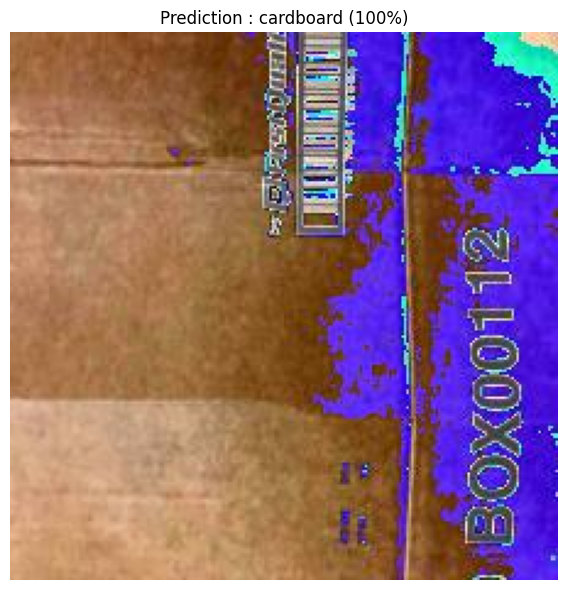

In [6]:
# Je collecte toutes les images disponibles dans les sous-dossiers images_pretraitees/{split}/{classe}/
images_root = os.path.join(base_dir, 'donnees', 'images_pretraitees')

if not os.path.exists(images_root):
    raise FileNotFoundError(f"Dossier d'images introuvable : {images_root}")

image_files = []
for split in os.listdir(images_root):
    split_dir = os.path.join(images_root, split)
    if not os.path.isdir(split_dir):
        continue
    for classe in os.listdir(split_dir):
        classe_dir = os.path.join(split_dir, classe)
        if not os.path.isdir(classe_dir):
            continue
        for fname in os.listdir(classe_dir):
            if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                image_files.append(os.path.join(classe_dir, fname))

if not image_files:
    raise FileNotFoundError(f"Aucune image trouvee dans {images_root}")

print(f"Total images disponibles : {len(image_files)}")

# Je teste le modele sur la premiere image disponible
img_path = image_files[0]
print(f"Image de test : {os.path.relpath(img_path, base_dir)}")

label, confidence, img, top3 = predict_image(img_path)

print(f"\nPrediction : {label}")
print(f"Confiance  : {confidence:.2%}")
print(f"\nTop {len(top3.values)} predictions :")
for i, (conf, idx) in enumerate(zip(top3.values, top3.indices)):
    print(f"  {i+1}. {CLASSES[idx.item()]} : {conf.item():.2%}")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Prediction : {label} ({confidence:.0%})")
plt.axis('off')
plt.tight_layout()
plt.show()

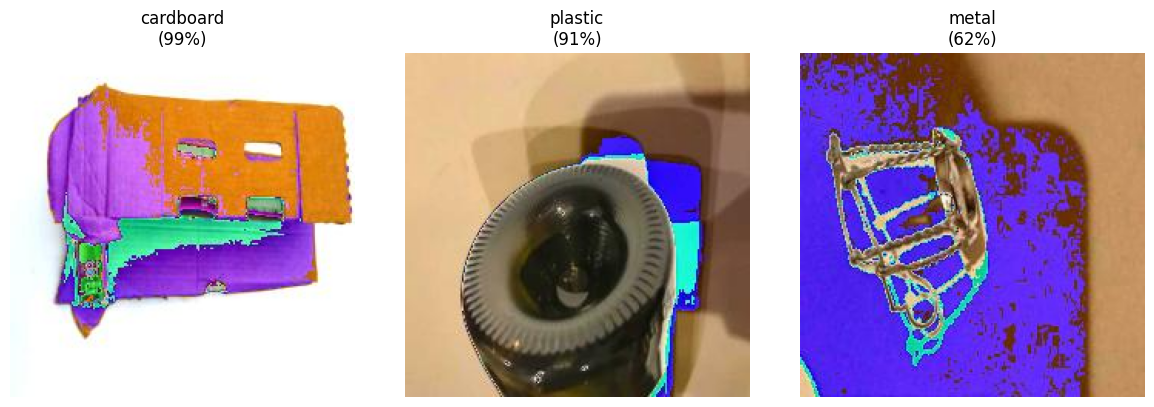

In [7]:
# Je teste le modele sur plusieurs images aleatoires pour evaluer visuellement ses predictions
import random

def test_multiple_images(num_images=5):
    selected = random.sample(image_files, min(num_images, len(image_files)))
    fig, axes = plt.subplots(1, len(selected), figsize=(4 * len(selected), 4))
    if len(selected) == 1:
        axes = [axes]
    for ax, path in zip(axes, selected):
        try:
            lbl, conf, img, _ = predict_image(path)
            ax.imshow(img)
            ax.set_title(f"{lbl}\n({conf:.0%})")
            ax.axis('off')
        except Exception as e:
            ax.text(0.5, 0.5, f"Erreur : {str(e)[:30]}", ha='center', va='center')
            ax.axis('off')
    plt.tight_layout()
    plt.show()

random.seed(42)
test_multiple_images(num_images=3)

---

**Conclusion**

Le modele charge correctement les images, effectue les predictions et retourne les scores de confiance par classe.